For Fig. 2C

In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(ggplot2)
library(showtext)
library(sysfonts)
})

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )

In [2]:
# Load data
df <- suppressWarnings(read.csv("data/T47D_U2OS_Cas12a.csv", check.names = TRUE))
names(df)[1] <- "Sample"
head(df)

,Sample,negative,negative.1,negative.2,negative.3,negative.4,negative.5,negative.6,negative.7,negative.8,⋯,U2OS.86,U2OS.87,U2OS.88,U2OS.89,U2OS.90,U2OS.91,U2OS.92,U2OS.93,U2OS.94,U2OS.95
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,nocrRNA,6864.20,15499.84,-1488.47,2494.45,5020.90,4249.93,10622.06,7143.72,7524.91,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,crRNA1,-1156.75,6154.16,-1762.56,-1018.21,5991.33,-9149.23,-7823.98,-655.67,3381.78,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,crRNA4,6853.42,4114.60,-1810.25,-883.84,827.71,-1688.79,-411.56,-3563.38,3521.23,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


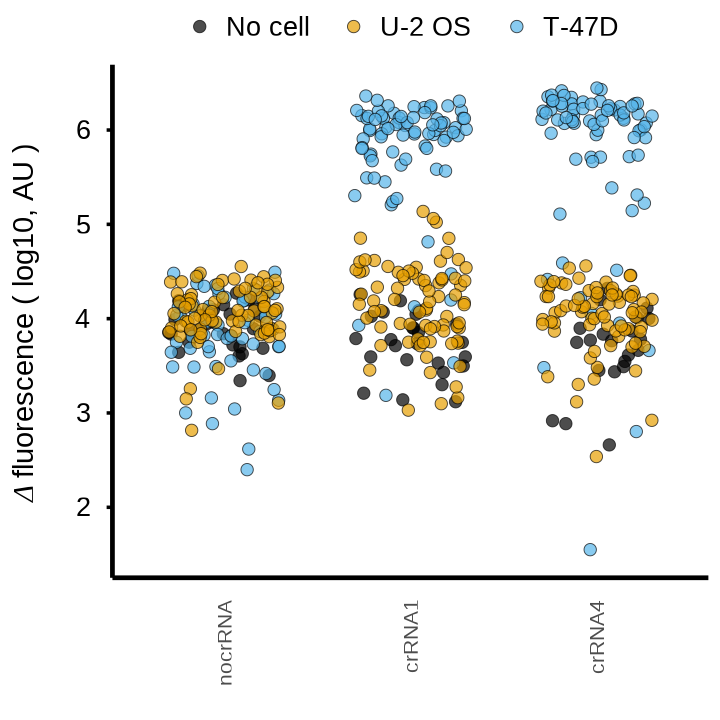

In [3]:
options(repr.plot.width = 6, repr.plot.height = 6)
# Reshape
df_long <- df %>%
  pivot_longer(
    cols = -Sample,
    names_to = "Condition",
    values_to = "Value"
  ) %>%
  filter(!is.na(Value) & Value != "") %>%
  mutate(
    Condition = str_replace(Condition, "\\.\\d+$", ""),
    Sample = factor(Sample, levels = c("nocrRNA", "crRNA1", "crRNA4"))  # custom order
  ) %>%
  filter(Value > 0) %>% # ✅ Keep only positive values 
  # Log10-transform the values
  mutate(Value = log10(Value))

#fix the order
df_long$Condition <- factor(df_long$Condition, levels = c( "negative", "U2OS", "T47D"))

# Plot
ggplot(df_long, aes(x = Sample, y = Value, fill = Condition)) +
  geom_jitter(
    color = "black",     # outline color
    width = 0.3,
    alpha = 0.7,
    size = 3,
    shape = 21,          # shape that supports fill
    stroke = 0.3         # outline thickness
  ) +
  scale_fill_manual(
    values = c(
      "negative" = "black",
      "T47D" = "#56B4E9",
      "U2OS"  = "#E69F00"
    ),
    labels = c(
      "negative" = "No cell",
      "T47D" = "T-47D",
      "U2OS"  = "U-2 OS"
    )
  ) +
  ylim(1.5, NA)+
  theme_minimal(base_size = 14) +
  ylab(expression(Delta * " fluorescence ( log10, AU )"))+
  theme(
    axis.text = element_text(size = 20),
    axis.text.x = element_text(size = 16, angle = 90, vjust = 0.5, hjust = 1, margin = margin(t = 10)),
    axis.text.y = element_text(size = 20, vjust = 0.5, hjust = 1, margin = margin(r = 10), color = "black"),
    axis.title.y = element_text(size = 22, margin = margin(r = 15), color = "black"), 
    axis.ticks.x = element_blank(),
    axis.title.x = element_blank(),
    axis.ticks.y = element_line(size = 0.75),
    legend.position = "top",
    legend.margin = margin(t = 0),
    legend.title = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1)
  )

In [4]:
ggsave("data/Cas12a_10mins.pdf", plot = last_plot(), width = 6, height = 6, units = "in")

In [5]:
table(df_long[df_long$Condition == "negative",]$Sample)


nocrRNA  crRNA1  crRNA4 
     31      25      21 

In [6]:
table(df_long[df_long$Condition == "T47D",]$Sample)


nocrRNA  crRNA1  crRNA4 
     60      79      76 

In [7]:
table(df_long[df_long$Condition == "U2OS",]$Sample)


nocrRNA  crRNA1  crRNA4 
     79      78      77 

In [8]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7  showtextdb_3.0  sysfonts_0.8.9  lubridate_1.9.4
 [5] forcats_1.0.0   stringr_1.5.2   dplyr_1.1.4     purrr_1.1.0    
 [9] readr_2.1.5     tidyr_1.3.1     tibble_3.3.0    ggplot2_3.5.2  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.